In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Experiment: MobileNetV2 + Triplet Loss - 40 Authors

Author identification experiment on handwritten documents using **Siamese Networks with Triplet Loss**.

**Objetive**: learn dn embedding space where patches from the same author cluster together and patches from different authors are pushed apart, enabling identification by similarity.

**Experiment setup**:
- Dataset: variant 4 (lines removed, grayscale)
- Authors: 40 (range 40)
- Architecture: MobileNetV2 fine-tuned + embedding head + triplet siamese network.

In [2]:
import os
import shutil
import datetime
import gc
import numpy as np
import tensorflow as tf
import random
from typing import Literal
import matplotlib.pyplot as plt
import pandas as pd
import math
from dataclasses import dataclass
from collections.abc import Iterable
from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
    roc_auc_score,
)
import seaborn as sns

In [3]:
!pip install "zarr>=2.16.0,<3.0.0" numcodecs umap-learn

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.3/211.3 kB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 156.9 MB/s eta 0:00:00
  Created wheel for asciitree: filename=asciitree-0.3.3-py3-none-any.whl size=5031 sha256=cd3e8d1510022b0b81a02a6ea0ad8406cb4fa82cfea088d4e2af570b868d14f7
  Stored in directory: /root/.cache/pip/wheels/a5/d7/98/f56ae733748cd0fa577172bda0e73e0b1f1793c98e09b9e458
Successfully built asciitree


In [ ]:
!pip install keras_hub keras

## Configuration

Configuration is split into dataclasses by domain of responsibility:

- ModelConfig - siamese network type (pair o triplet)
- `DataConfig` - selected authors and image shapes
- TrainingConfig - training hyperparameters
- BatchConfig - batch sizes per split

**Key decisions**:
- val_ratio=0.25 - fraction on non-test data reserved for validation
- epochs=30 - maximum training epochs (early stopping may trigger earlier)

In [4]:
ModelType = Literal["pair", "triplet"]

@dataclass
class ModelConfig:
    type: ModelType

@dataclass
class DataConfig:
    authors_range: Iterable[int]
    original_shape: tuple[int, int, int]
    model_input_shape: tuple[int, int, int]

    def __post_init__(self):
        authors_array = np.asarray(list(self.authors_range))

        if authors_array.ndim != 1 or len(authors_array) == 0:
            raise ValueError("authors_range must be a non-empty 1D iterable")

        if len(np.unique(authors_array)) != len(authors_array):
            raise ValueError("authors_range contains duplicates")

        self.authors_range = authors_array
        self.authors = len(authors_array)


@dataclass
class TrainingConfig:
    epochs: int
    seed: int
    val_ratio: float

    def __post_init__(self):
        assert 0 < self.val_ratio < 1, "val_ratio must be between 0 and 1"


@dataclass
class BatchConfig:
    train: int
    validation: int
    test: int

    def __post_init__(self):
        assert self.train > 0
        assert self.validation > 0
        assert self.test > 0


@dataclass
class Config:
    project_path: str
    dataset: str
    model: ModelConfig
    data: DataConfig
    training: TrainingConfig
    batch: BatchConfig
    current_time: str

In [5]:
config = Config(
    project_path='drive/MyDrive/author-handwriting-recog',
    dataset='dataset_4_ImagesLinesRemoved_20260310-153450',
    model=ModelConfig(type="triplet"),
    data=DataConfig(
        authors_range=range(0, 40),
        original_shape=(180, 360, 1),
        model_input_shape=(120, 240, 3),
    ),
    training=TrainingConfig(
        epochs=30,
        seed=42,
        val_ratio=0.25
    ),
    batch=BatchConfig(
        train=16,
        validation=8,
        test=4,
    ),
    current_time=datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
)

In [6]:
def upload_source(source: str, source_dest: str):
    if os.path.exists(source_dest):
        shutil.rmtree(source_dest)

    shutil.copytree(source, source_dest)

In [7]:
upload_source(
    source=f"{config.project_path}/src",
    source_dest="./src"
)

In [8]:
upload_source(
    source=f"{config.project_path}/data/datasets/180_360_90",
    source_dest=f"./dataset"
)

In [9]:
upload_source(
    source=f"{config.project_path}/data/datasets/experiments",
    source_dest="./models"
)

In [10]:
random.seed(config.training.seed)
np.random.seed(config.training.seed)
tf.random.set_seed(config.training.seed)

In [11]:
from src.io import LoggerFactory
from src.datasets.loaders import SelectiveDataLoader
from src.generators import (
    AugmentationPipeline,
    AugmentationOps,
    AugmentImage,
    BaseGenerator,
    DataGenerator,
    TripletGenerator,
)

In [12]:
from src.models import (
    MobileNetV2Backbone,
    TripletLoss,
    EmbeddingNetwork,
    SiameseFactory
)
from src.training import (
    get_default_callbacks,
    ModelTrainerFactory,
    BaseMetricTrainer,
)
from src.evaluator import (
    TripletEvaluator,
    EmbeddingEvaluator,
    EmbeddingVisualizer,
)

In [13]:
from src.evaluator.embedding_utils import EmbeddingExtractor, UMAPReducer
from src.evaluator.embedding_strategy import (
    StrategyPipeline,
    OneNNStrategy,
    MeanStrategy,
    CentroidStrategy,
    TopKStrategy,
    PatchAggregator,
    VoteAggregator,
    ScoreAggregator,
)

In [14]:
logger = LoggerFactory.get_logger(
    "mobile_test_40_4",
    log_dir=f"./logs_{config.current_time}",
    file_prefix=f"mobile_triplet_{config.current_time}"
)

In [15]:
dataset_path = f"dataset/{config.dataset}.tar.gz"

In [16]:
!tar -xzf {dataset_path} -C ./

## Dataset

The dataset is stored in .zarr format with spatial separation between train and test:

```
dataset.zarr
├── non_test/   ← patches from the main writing area (train + val)
└── test/       ← patches from the test area, physically separated in the original image
```

`SelectiveDataLoader` selects a subset of authors and builds the three splits (train, val, test) guaranteeing that **no patch from the test area appears in train o val**.
This eliminates data leakage by spatial position.

In [17]:
loader = SelectiveDataLoader(
    dataset_path=f"./{config.dataset}.zarr",
    logger=logger,
    seed=config.training.seed
)

In [18]:
train, val, test = loader.build(
      authors=config.data.authors_range,
      validation_fraction=config.training.val_ratio,
  )

13:32:44 - mobile_test_40_4 - INFO - Total patches selected: 25147
13:32:44 - mobile_test_40_4 - INFO - Train: 18860 | Val: 6287 | Test: 1733
13:32:44 - mobile_test_40_4 - INFO - Avg non_test patches per author: 628.67 | Min: 399 | Max: 808
13:32:44 - mobile_test_40_4 - INFO - Avg test patches per author: 43.33 | Min: 34 | Max: 48
13:32:44 - mobile_test_40_4 - INFO - Image shape: (180, 360)
13:32:44 - mobile_test_40_4 - INFO - Zarr chunk shape: (64, 180, 360)


## Augmentation

Two distinct pipelines are used:

- **pipeline_train** - full augmentation: rotation, zoom, shift, noise, brightness, contrast
- **pipeline** - resize _ normalization only (no perturbations)

The training pipeline introduces artificial variability to improve generaliaztion. The validation/test pipeline is deterministic for reproducible evaluation.

> mobilenet_preprocess at the end is required - it normalizes pixel values to the range
> expected by MobileNetV2 (ImageNet statistics)

In [19]:
ops = AugmentationOps(
    rotation_range=6,
    width_shift_range=0.04,
    height_shift_range=0.05,
    horizontal_flip=False,
    resize_dim=config.data.model_input_shape[:2],
    brightness_delta=0.04,
    contrast_range=(0.95, 1.05),
    noise_stddev=0.01,
    zoom_range=(0.95, 1.05),
)
pipeline_train = AugmentationPipeline([
    ops.rotate,
    ops.zoom,
    ops.shift,
    ops.resize,
    ops.to_rgb,
    ops.clip_255,
    ops.mobilenet_preprocess,
])
pipeline = AugmentationPipeline([
    ops.resize,
    ops.to_rgb,
    ops.clip_255,
    ops.mobilenet_preprocess,
])
augment_train = AugmentImage(pipeline_train)
augment = AugmentImage(pipeline)

In [20]:
train_triplet = TripletGenerator(
    split=train,
    batch_size=config.batch.train,
    seed=config.training.seed,
    augment=augment_train
)
val_triplet = TripletGenerator(
    split=val,
    batch_size=config.batch.validation,
    seed=config.training.seed,
    augment=augment
)
test_triplet = TripletGenerator(
    split=test,
    batch_size=config.batch.test,
    seed=config.training.seed,
    augment=augment
)

In [21]:
def display_generator_info(generator: BaseGenerator):
    config = generator.get_config()
    logger.info(f"Generator: {generator.__class__.__name__}")
    logger.info(f"Number of samples: {config['num_samples']}")
    logger.info(f"Batch size: {config['batch_size']}")
    logger.info(f"Steps per epoch: {config['steps_per_epoch']}")
    logger.info(f"Shape: {config['patch_shape']}")
    logger.info(f"Number of authors: {config['num_authors']}")

In [22]:
display_generator_info(train_triplet)

13:32:45 - mobile_test_40_4 - INFO - Generator: TripletGenerator
13:32:45 - mobile_test_40_4 - INFO - Number of samples: 18860
13:32:45 - mobile_test_40_4 - INFO - Batch size: 16
13:32:45 - mobile_test_40_4 - INFO - Steps per epoch: 1179
13:32:45 - mobile_test_40_4 - INFO - Shape: (180, 360)
13:32:45 - mobile_test_40_4 - INFO - Number of authors: 40


In [23]:
display_generator_info(val_triplet)

13:32:45 - mobile_test_40_4 - INFO - Generator: TripletGenerator
13:32:45 - mobile_test_40_4 - INFO - Number of samples: 6287
13:32:45 - mobile_test_40_4 - INFO - Batch size: 8
13:32:45 - mobile_test_40_4 - INFO - Steps per epoch: 786
13:32:45 - mobile_test_40_4 - INFO - Shape: (180, 360)
13:32:45 - mobile_test_40_4 - INFO - Number of authors: 40


In [24]:
display_generator_info(test_triplet)

13:32:45 - mobile_test_40_4 - INFO - Generator: TripletGenerator
13:32:45 - mobile_test_40_4 - INFO - Number of samples: 1733
13:32:45 - mobile_test_40_4 - INFO - Batch size: 4
13:32:45 - mobile_test_40_4 - INFO - Steps per epoch: 434
13:32:45 - mobile_test_40_4 - INFO - Shape: (180, 360)
13:32:45 - mobile_test_40_4 - INFO - Number of authors: 40


## Model Construction

The architecture follows a chain of separated responsibilities:

```
MobileNetV2Backbone         → extracts visual features (pre-trained on ImageNet)
    ↓
EmbeddingNetwork            → projects features to an L2-normalized embedding space
    ↓
SiameseFactory              → builds the triplet siamese network (anchor, positive, negative)
    ↓
ModelTrainerFactory         → wraps the network in a trainer with training/eval logic
```

**`trainer.siamese_network`** — full triplet network, used during training.
**`trainer.embedding_model`** — backbone + embedding head, used to extract embeddings at evaluation time.
Both share the same weights in memory.

In [25]:
embedding_network = EmbeddingNetwork(
    backbone=MobileNetV2Backbone(freeze_base=False, fine_tune_at=100),
    input_shape=config.data.model_input_shape,
    num_authors=config.data.authors,
)

In [26]:
siamese_builder = SiameseFactory.create(
    model_type=config.model.type,
    embedding_network=embedding_network,
    input_shape=config.data.model_input_shape,
)

In [27]:
trainer = ModelTrainerFactory.create(
    siamese_builder=siamese_builder,
    train_generator=train_triplet,
    val_generator=val_triplet,
    model_name="mobilenet_triplet",
    model_type=config.model.type,
)

In [28]:
trainer.initialize_model()

/content/src/models/backbones/mobile_net.py:13: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


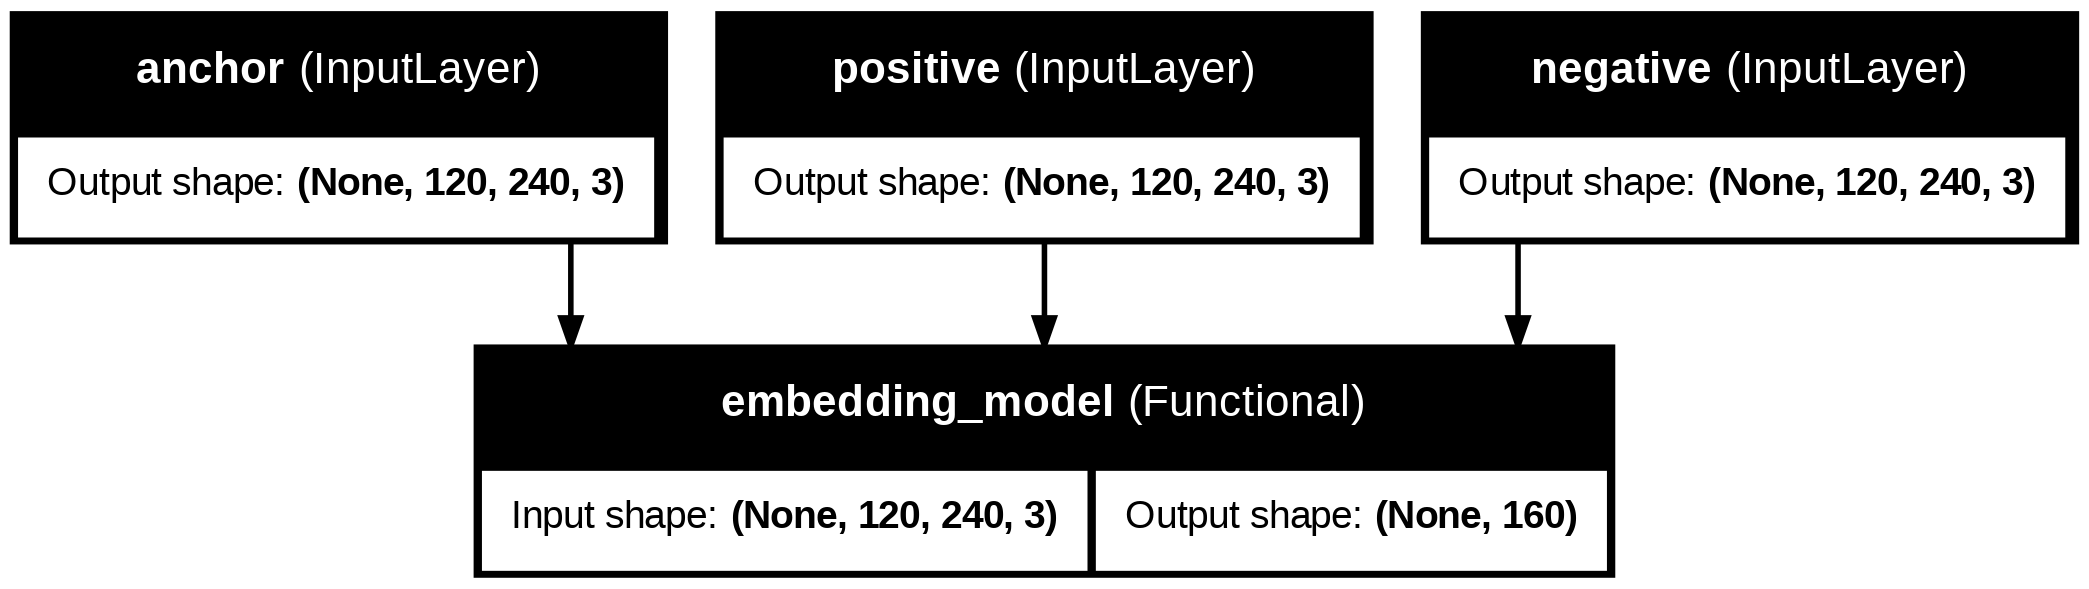

In [ ]:
tf.keras.utils.plot_model(
    trainer.siamese_network,
    show_shapes=True,
    show_layer_names=True,
)

In [ ]:
trainer.siamese_network.summary()

Model: "siamese_triplet_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ anchor (InputLayer) │ (None, 120, 240,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positive            │ (None, 120, 240,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ negative            │ (None, 120, 240,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_model     │ (None, 160)       │  2,721,184 │ anchor[0][0],     │
│ (Functional)        │                   │            │ positive[0][0],   │
│                     │                   │            │ negative[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,721,184 (10.38 MB)

 Trainable params: 2,323,680 (8.86 MB)

 Non-trainable params: 397,504 (1.52 MB)

In [ ]:
trainer.embedding_model.summary()

Model: "embedding_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 120, 240, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 4, 8, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 320)            │       409,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 320)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 320)            │         1,280 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 160)            │        51,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 160)            │           640 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ l2_normalization                │ (None, 160)            │             0 │
│ (L2Normalization)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,721,184 (10.38 MB)

 Trainable params: 2,323,680 (8.86 MB)

 Non-trainable params: 397,504 (1.52 MB)

## Compilation and Training

**TripletLoss** with margin=0.4:
minimizes max(d(a, p) - d(a, n) + margin, 0) where d is cosine distance.

**Monirored metrics**:
- ap_sim - average cosine similarity between anchor and positive (want: high)
- an_sim - average cosine similarity between anchor and negative (want: low)
- margin - difference ap_sim - an_sim (want: positive and increasin)
- triplet_acc - fraction of triplets where ap_sim > an_sim

**Callbacks**:
- EarlyStopping(patience=4) - stops training if vall_loss does not improve
- ReduceLROPlateau(patience=2) - reduces learning rate on plateau
- start_from_epoch=5 - early stopping is inactive during warm-up epochs

In [29]:
trainer.compile(
    loss=TripletLoss(margin=0.4),
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    metrics=[
        tf.keras.metrics.Mean(name="ap_sim"),
        tf.keras.metrics.Mean(name="an_sim"),
        tf.keras.metrics.Mean(name="margin"),
        tf.keras.metrics.Mean(name="triplet_acc"),
    ],
)

In [ ]:
callbacks = get_default_callbacks(
    model_name="mobile_siamese_triplet",
    monitor="val_loss",
    mode="min",
    patience=4,
    start_from_epoch=5,
    reduce_lr_patience=2,
)

In [ ]:
history = trainer.train_model(
    epochs=config.training.epochs,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30
1179/1179 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - an_sim: -0.0014 - ap_sim: 0.0367 - loss: 0.3628 - margin: 0.0381 - triplet_acc: 0.5962
Epoch 1: val_loss improved from None to 0.32243, saving model to checkpoints/mobile_siamese_triplet/best.keras

Epoch 1: finished saving model to checkpoints/mobile_siamese_triplet/best.keras
1179/1179 ━━━━━━━━━━━━━━━━━━━━ 222s 139ms/step - an_sim: 9.3276e-04 - ap_sim: 0.0572 - loss: 0.3466 - margin: 0.0562 - triplet_acc: 0.6208 - val_an_sim: 0.0734 - val_ap_sim: 0.1566 - val_loss: 0.3224 - val_margin: 0.0832 - val_triplet_acc: 0.6622 - learning_rate: 1.0000e-05
Epoch 2/30
1177/1179 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - an_sim: 1.5654e-04 - ap_sim: 0.1475 - loss: 0.2805 - margin: 0.1474 - triplet_acc: 0.7079
Epoch 2: val_loss improved from 0.32243 to 0.25386, saving model to checkpoints/mobile_siamese_triplet/best.keras

Epoch 2: finished saving model to checkpoints/mobile_siamese_triplet/best.keras
1179/1179 ━━━━━━━━━━━━━━━━━━━━ 94s 79ms/step - 

In [ ]:
def plot_keras_history(history: tf.keras.callbacks.History):

    df = pd.DataFrame(history.history)

    metrics = [col for col in df.columns if not col.startswith("val_")]

    n_metrics = len(metrics)
    n_cols = 2
    n_rows = math.ceil(n_metrics / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))
    axes = axes.flatten()

    for i, metric in enumerate(metrics):
        ax = axes[i]

        ax.plot(df[metric], label=f"train_{metric}")

        val_metric = f"val_{metric}"
        if val_metric in df.columns:
            ax.plot(df[val_metric], label=f"val_{metric}")

        ax.set_title(metric)
        ax.set_xlabel("Epoch")
        ax.legend()

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

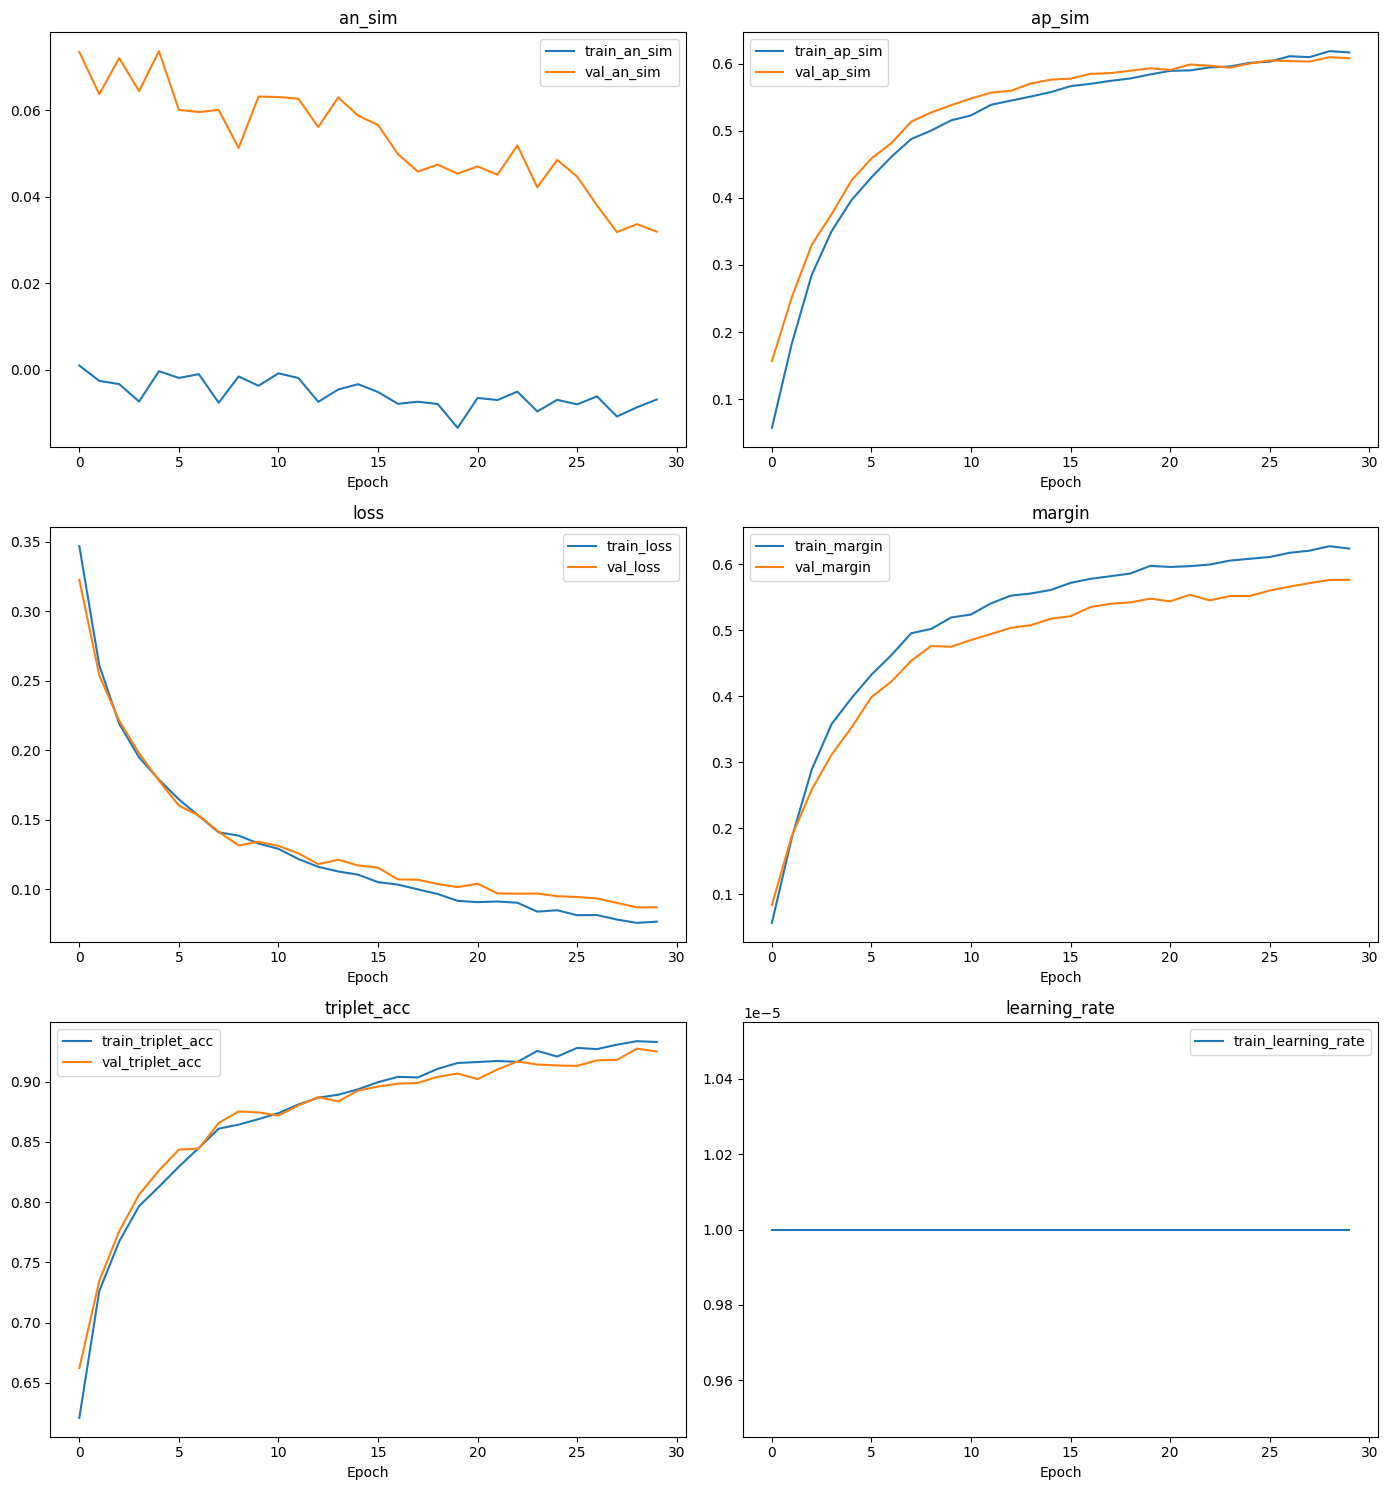

In [ ]:
plot_keras_history(history)

In [ ]:
def save_model(model: BaseMetricTrainer, path: str):
    model.siamese_network.save(f"{path}/mobilenet_siamese_model_40_{config.current_time}.keras")
    model.embedding_model.save(f"{path}/mobilenet_embedding_model_40_{config.current_time}.keras")

In [ ]:
save_model(model=trainer, path="./models")

In [ ]:
save_model(model=trainer, path=f"./{config.project_path}/data/datasets/experiments")

In [30]:
trainer.siamese_network.load_weights("./models/mobilenet_siamese_model_40_20260326-120653.keras")

In [ ]:
metrics_val = trainer.evaluate_dict(val_triplet)
metrics_val

786/786 ━━━━━━━━━━━━━━━━━━━━ 19s 24ms/step - an_sim: 0.0325 - ap_sim: 0.6107 - loss: 0.0877 - margin: 0.5782 - triplet_acc: 0.9233


{'an_sim': 0.03249029070138931,
 'ap_sim': 0.6106554865837097,
 'loss': 0.08774778991937637,
 'margin': 0.5781652331352234,
 'triplet_acc': 0.9233338832855225}

In [ ]:
metrics_test = trainer.evaluate_dict(test_triplet)
metrics_test

434/434 ━━━━━━━━━━━━━━━━━━━━ 38s 50ms/step - an_sim: -0.0093 - ap_sim: 0.6340 - loss: 0.0692 - margin: 0.6433 - triplet_acc: 0.9435


{'an_sim': -0.009266280569136143,
 'ap_sim': 0.6340460181236267,
 'loss': 0.06917429715394974,
 'margin': 0.6433125734329224,
 'triplet_acc': 0.9434506893157959}

In [ ]:
def build_author_confusion_matrix(
    df: pd.DataFrame,
    true_col: str = "author_i",
    pred_col: str = "author_j"
) -> pd.DataFrame:
    authors = sorted(df[true_col].unique())

    cm = confusion_matrix(
        df[true_col],
        df[pred_col],
        labels=authors
    )

    cm_df = pd.DataFrame(
        cm,
        index=authors,
        columns=authors
    )

    return cm_df

In [ ]:
def display_heatmap(
    df: pd.DataFrame,
    title: str = "Confusion Matrix",
    show_accuracy: bool = True,
) -> None:
    """
    Display confusion matrix heatmap with optional accuracy in title.
    """

    if show_accuracy:
        correct = np.trace(df.values)
        total = df.values.sum()
        acc = correct / total if total > 0 else 0.0

        title = f"{title} (Acc={acc:.3f})"

    plt.figure(figsize=(10, 8))
    sns.heatmap(df, cmap="Blues", linewidths=0.5)

    plt.xlabel("Predicted Author")
    plt.ylabel("True Author")
    plt.title(title)

    plt.show()

## Triplet Evaluation

`TripletEvaluator` evaluates the model in terms of **pairwise similarity**:

- Generates triplets (anchor, positive, negative) from the test set
- Computes cosine similarity between anchor-positive and anchor-negative pairs
- **AUC** — ability to discriminate similar pairs from dissimilar ones
- **Triplet accuracy** — % of triplets where `sim(a,p) > sim(a,n)`

This evaluation measures the quality of the similarity space,
independently of the author identification strategy.

In [ ]:
triplet_evaluator = TripletEvaluator(
    siamese_network=trainer.siamese_network,
    logger=logger,
)

In [ ]:
triplet_evaluator.data_generator = test_triplet
triplet_report = triplet_evaluator.evaluate()

11:05:13 - mobile_test_40_4 - INFO - === Triplet Evaluation Started ===
11:05:15 - mobile_test_40_4 - INFO - === Collecting triplet results ===
11:05:33 - mobile_test_40_4 - INFO - Total triplets collected: 434
11:05:33 - mobile_test_40_4 - INFO - [LOCAL] acc=0.9394 gap=0.6402 error=0.0606 auc=0.9419
11:05:33 - mobile_test_40_4 - INFO - === Computing global metrics ===
11:05:33 - mobile_test_40_4 - INFO - === Global metrics computed ===
11:05:33 - mobile_test_40_4 - INFO - === Triplet Evaluation Finished ===


In [ ]:
logger.info(
    f"AUC: {triplet_report.local_metrics.auc}, "
    f"Accuracy: {triplet_report.local_metrics.triplet_accuracy}"
)

11:05:33 - mobile_test_40_4 - INFO - AUC: 0.9418697301525094, Accuracy: 0.9394114252740912


In [ ]:
y_true = np.concatenate([
    np.ones(len(triplet_report.df_triplets)),
    np.zeros(len(triplet_report.df_triplets))
])
y_pred = np.concatenate([
    triplet_report.df_triplets["sim_ap"].values,
    triplet_report.df_triplets["sim_an"].values
])

### ROC Curve

The `ROC curve` evaluates the ability of the embedding space to distinguish between positive (same writer) and negative (different writer) pairs across all possible similarity thresholds.
The high `AUC` (≈0.94) indicates that the model learns a well-structured embedding space where genuine pairs are consistently assigned higher similarity scores than impostor pairs.

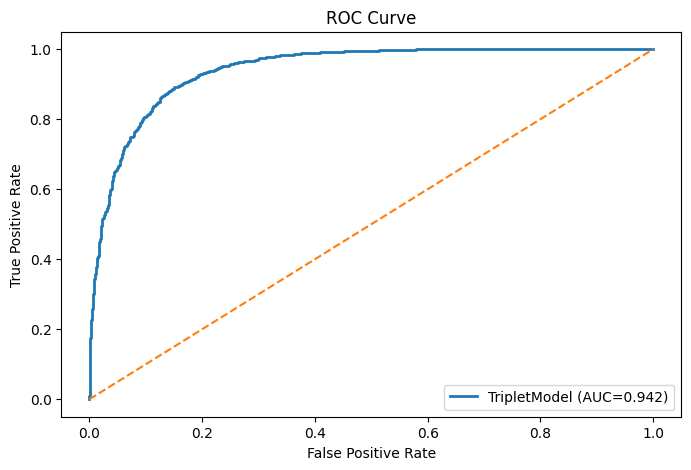

In [ ]:
fpr, tpr, thresholds = roc_curve(y_true, y_pred)
auc = roc_auc_score(y_true, y_pred)

plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, lw=2, label=f'TripletModel (AUC={auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")

plt.show()

### Precision-Recall Curve

The `precision-recall` analysis highlights the trade-off between correctly identifying matching pairs (recall) and avoiding false matches (precision).
As expected, lower thresholds increase recall but introduce more false positives, while higher thresholds improve precision at the cost of missing true matches.
This curve is useful for selecting an operating threshold depending on the application requirements.

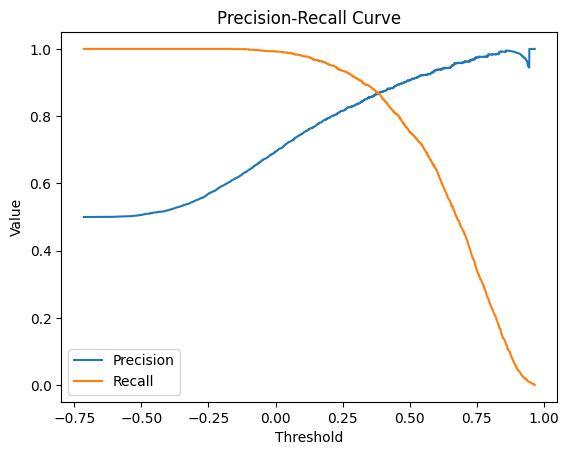

In [ ]:
precision, recall, thresholds_pr = precision_recall_curve(y_true, y_pred)

plt.figure()
plt.plot(thresholds_pr, precision[:-1], label='Precision')
plt.plot(thresholds_pr, recall[:-1], label='Recall')

plt.xlabel('Threshold')
plt.ylabel('Value')
plt.title('Precision-Recall Curve')
plt.legend()

plt.show()

### Similarity Distribution

The similarity distribution plot shows the separation between positive pairs (same writer) and negative pairs (different writers) in the embedding space.
Positive pairs tend to have higher similarity values, while negative pairs are mostly concentrated in lower similarity regions.
This indicates that the model successfully learns a meaningful representation where samples from the same writer are closer in the feature space.

However, there is a noticeable overlap between the two distributions, particularly in the mid-range similarity values.
This overlap corresponds to ambiguous cases where the model struggles to distinguish between similar handwriting styles, leading to potential false positives and false negatives.

The degree of overlap explains why the model does not achieve perfect accuracy, despite the high AUC and triplet accuracy scores.
Reducing this overlap is key to further improving the model performance.

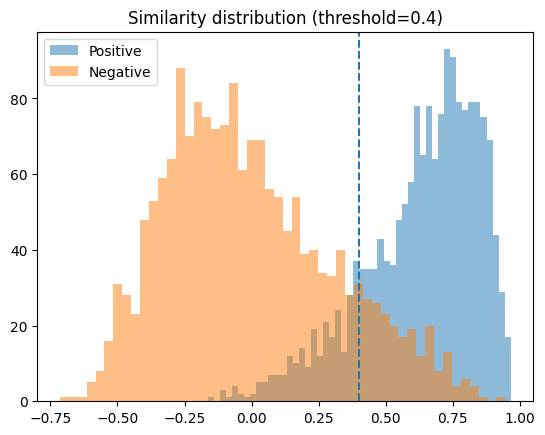

In [ ]:
plt.hist(triplet_report.df_triplets["sim_ap"], bins=50, alpha=0.5, label="Positive")
plt.hist(triplet_report.df_triplets["sim_an"], bins=50, alpha=0.5, label="Negative")
plt.axvline(0.4, linestyle='--')
plt.legend()
plt.title("Similarity distribution (threshold=0.4)")
plt.show()

### Confusion Matrix

The `confusion matrix` provides insight into which writers are more frequently confused by the model.
Strong diagonal values indicate correct identification, while off-diagonal entries reveal pairs of writers with similar handwriting characteristics.
This analysis helps identify systematic errors and potential limitations of the learned embedding space.

**Triplet-level Confusion Matrix**

The first confusion matrix is computed from individual triplet predictions.

Each decision is based on a local comparison between a positive and a negative sample.

This matrix reflects how often the model assigns the correct writer label in pairwise similarity decisions.

Due to the local nature of these comparisons, the matrix may contain noise and variability.

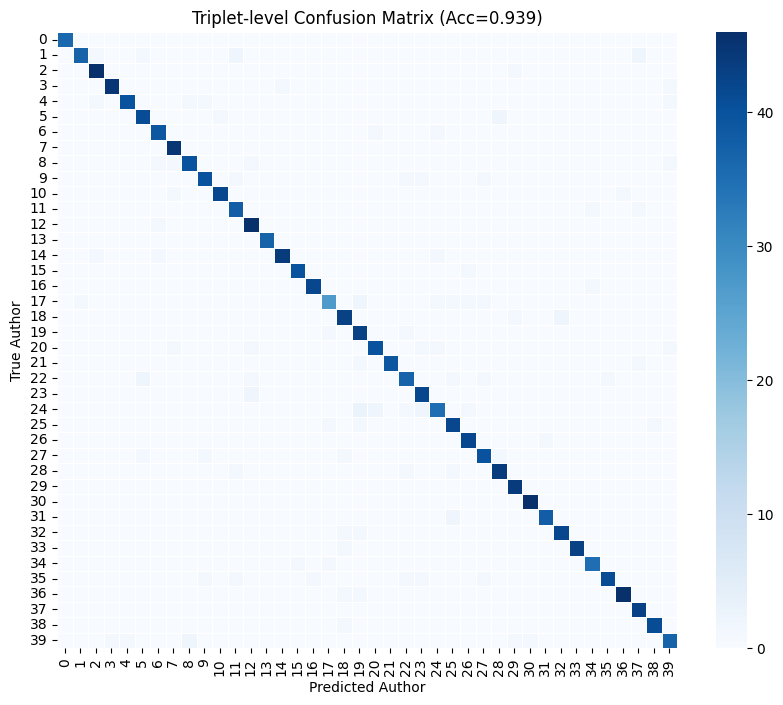

In [ ]:
cm_df = build_author_confusion_matrix(
    triplet_report.df_triplets,
    true_col="anchor_label",
    pred_col="pred_label"
)
display_heatmap(cm_df, title="Triplet-level Confusion Matrix")

**Author-level Confusion Matrix**

The second confusion matrix is derived from aggregated metrics across triplets.

For each writer, the model selects the most representative prediction based on a scoring function combining accuracy and similarity gap.

This results in a more stable and global evaluation of the model’s ability to distinguish between different writers.

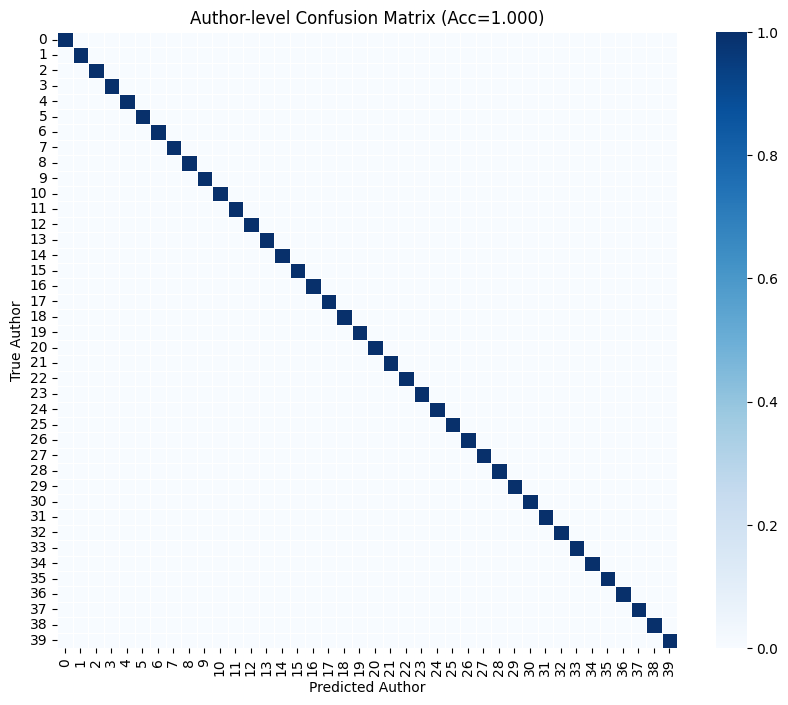

In [ ]:
cm_df = build_author_confusion_matrix(
    triplet_report.global_metrics.df_by_score,
    true_col="anchor_label",
    pred_col="pred_label"
)
display_heatmap(cm_df, title="Author-level Confusion Matrix")

**Comparison**

While the triplet-level matrix evaluates local decision quality, the author-level matrix reflects global identification performance.

Together, they provide a comprehensive understanding of both the embedding quality and the consistency of writer discrimination.

In [ ]:
triplet_report.global_metrics.df_by_score

,anchor_label,pred_label,accuracy,mean_gap,count,gap_norm,score
0,0,0,1.0,0.852363,36,0.941211,0.941211
1,1,1,1.0,0.661891,37,0.825506,0.825506
2,2,2,1.0,0.901802,46,0.971244,0.971244
3,3,3,1.0,0.687361,45,0.840979,0.840979
4,4,4,1.0,0.676461,40,0.834357,0.834357
5,5,5,1.0,0.767083,41,0.889407,0.889407
6,6,6,1.0,0.684629,39,0.839319,0.839319
7,7,7,1.0,0.924037,45,0.984751,0.984751
8,8,8,1.0,0.751816,40,0.880133,0.880133
9,9,9,1.0,0.559441,40,0.763271,0.763271


In [31]:
val_gen = DataGenerator(
    split=val,
    batch_size=config.batch.validation,
    seed=config.training.seed,
    augment=augment
)
test_gen = DataGenerator(
    split=test,
    batch_size=config.batch.test,
    seed=config.training.seed,
    augment=augment
)

In [32]:
display_generator_info(val_gen)

13:32:50 - mobile_test_40_4 - INFO - Generator: DataGenerator
13:32:50 - mobile_test_40_4 - INFO - Number of samples: 6287
13:32:50 - mobile_test_40_4 - INFO - Batch size: 8
13:32:50 - mobile_test_40_4 - INFO - Steps per epoch: 786
13:32:50 - mobile_test_40_4 - INFO - Shape: (180, 360)
13:32:50 - mobile_test_40_4 - INFO - Number of authors: 40


In [33]:
display_generator_info(test_gen)

13:32:50 - mobile_test_40_4 - INFO - Generator: DataGenerator
13:32:50 - mobile_test_40_4 - INFO - Number of samples: 1733
13:32:50 - mobile_test_40_4 - INFO - Batch size: 4
13:32:50 - mobile_test_40_4 - INFO - Steps per epoch: 434
13:32:50 - mobile_test_40_4 - INFO - Shape: (180, 360)
13:32:50 - mobile_test_40_4 - INFO - Number of authors: 40


## Embedding Evaluation

The main evaluation of the identification system.

**`EmbeddingExtractor`** uses `trainer.embedding_model` (not the full siamese network)
to extract one embedding per patch from the test set.

**Distance metrics:**
- `intra_distance` — average distance between patches from the **same** author
- `inter_distance` — average distance between patches from **different** authors
- A ratio `inter/intra >> 1` indicates good class separation in the embedding space

**Identification strategies:**
| Strategy | How it predicts the author of a patch |
|---|---|
| `1nn` | author of the nearest patch in the embedding space |
| `mean` | author whose mean embedding is most similar |
| `centroid` | author whose centroid (mean of train embeddings) is closest |
| `topk` | most frequent author among the K nearest neighbors |

**Aggregators — how predictions are aggregated at author level:**
| Aggregator | Logic |
|---|---|
| `patch` | accuracy per individual patch |
| `vote` | majority vote over all patches of the author |
| `score` | prediction by maximum average similarity |

> **The primary metric is `vote accuracy`.**
> Low patch accuracy (~60-80%) is expected and does not indicate model failure —
> an isolated patch can be ambiguous. Author identity emerges by aggregating
> evidence from multiple patches.

In [34]:
extractor = EmbeddingExtractor(
    model=trainer.embedding_model,
    logger=logger,
)

In [35]:
strategy_pipeline = StrategyPipeline(
    strategies=[
        OneNNStrategy(), MeanStrategy(), CentroidStrategy(), TopKStrategy(k=5),
    ],
    aggregators=[PatchAggregator(), VoteAggregator(), ScoreAggregator()],
    logger=logger,
)

In [36]:
emb_evaluator = EmbeddingEvaluator(
    extractor=extractor,
    pipeline=strategy_pipeline,
    logger=logger,
    seed=config.training.seed
)

In [37]:
val_gen_results = emb_evaluator.evaluate(val_gen)

13:32:50 - mobile_test_40_4 - INFO - [EmbeddingEvaluator] Starting evaluation
13:32:50 - mobile_test_40_4 - INFO - Extracting embeddings from the model
13:32:51 - mobile_test_40_4 - INFO - Processing 786 batches to extract embeddings
13:34:52 - mobile_test_40_4 - INFO - Extracted embeddings for 6287 samples
13:34:52 - mobile_test_40_4 - INFO - [EmbeddingEvaluator] Embeddings shape=(6287, 160)
13:34:52 - mobile_test_40_4 - INFO - [EmbeddingEvaluator] Computing intra/inter distances
13:34:52 - mobile_test_40_4 - INFO - [EmbeddingEvaluator] Reducing dimensionality with UMAP


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


13:35:22 - mobile_test_40_4 - INFO - [EmbeddingEvaluator] Evaluating strategies
13:35:22 - mobile_test_40_4 - INFO - Applying strategy pipeline with 4 strategies and 3 aggregators.
13:35:22 - mobile_test_40_4 - INFO - Applying strategy: 1nn
13:35:22 - mobile_test_40_4 - INFO - Applying aggregator: patch
13:35:22 - mobile_test_40_4 - INFO - Applying aggregator: vote
13:35:22 - mobile_test_40_4 - INFO - Applying aggregator: score
13:35:22 - mobile_test_40_4 - INFO - patch acc=0.5911Strategy '1nn' results: , vote acc=1.0000Strategy '1nn' results: , score acc=1.0000
13:35:22 - mobile_test_40_4 - INFO - Applying strategy: mean
13:35:29 - mobile_test_40_4 - INFO - Applying aggregator: patch
13:35:29 - mobile_test_40_4 - INFO - Applying aggregator: vote
13:35:29 - mobile_test_40_4 - INFO - Applying aggregator: score
13:35:29 - mobile_test_40_4 - INFO - patch acc=0.5491Strategy 'mean' results: , vote acc=0.7750Strategy 'mean' results: , score acc=0.7750
13:35:29 - mobile_test_40_4 - INFO - App

In [38]:
logger.info(f"Intra distance: {val_gen_results.intra_distance}")
logger.info(f"Inter distance: {val_gen_results.inter_distance}")

for strategy_name, agg_results in val_gen_results.strategy_results.items():

    logger.info(f"Strategy: {strategy_name}")

    for agg_name, result in agg_results.items():
        acc = result.metrics.get("accuracy", np.nan)
        logger.info(f"{agg_name.capitalize()} accuracy: {acc:.4f}")

    logger.info(f"{'-'*40}")

13:35:41 - mobile_test_40_4 - INFO - Intra distance: 0.38858747482299805
13:35:41 - mobile_test_40_4 - INFO - Inter distance: 0.9594342708587646
13:35:41 - mobile_test_40_4 - INFO - Strategy: 1nn
13:35:41 - mobile_test_40_4 - INFO - Patch accuracy: 0.5911
13:35:41 - mobile_test_40_4 - INFO - Vote accuracy: 1.0000
13:35:41 - mobile_test_40_4 - INFO - Score accuracy: 1.0000
13:35:41 - mobile_test_40_4 - INFO - ----------------------------------------
13:35:41 - mobile_test_40_4 - INFO - Strategy: mean
13:35:41 - mobile_test_40_4 - INFO - Patch accuracy: 0.5491
13:35:41 - mobile_test_40_4 - INFO - Vote accuracy: 0.7750
13:35:41 - mobile_test_40_4 - INFO - Score accuracy: 0.7750
13:35:41 - mobile_test_40_4 - INFO - ----------------------------------------
13:35:41 - mobile_test_40_4 - INFO - Strategy: centroid
13:35:41 - mobile_test_40_4 - INFO - Patch accuracy: 0.6051
13:35:41 - mobile_test_40_4 - INFO - Vote accuracy: 1.0000
13:35:41 - mobile_test_40_4 - INFO - Score accuracy: 1.0000
13:

In [39]:
test_gen_results = emb_evaluator.evaluate(
    data_generator=test_gen,
    reducer=UMAPReducer(n_components=3),
)

13:35:41 - mobile_test_40_4 - INFO - [EmbeddingEvaluator] Starting evaluation
13:35:41 - mobile_test_40_4 - INFO - Extracting embeddings from the model
13:35:41 - mobile_test_40_4 - INFO - Processing 434 batches to extract embeddings
13:36:46 - mobile_test_40_4 - INFO - Extracted embeddings for 1733 samples
13:36:46 - mobile_test_40_4 - INFO - [EmbeddingEvaluator] Embeddings shape=(1733, 160)
13:36:46 - mobile_test_40_4 - INFO - [EmbeddingEvaluator] Computing intra/inter distances
13:36:46 - mobile_test_40_4 - INFO - [EmbeddingEvaluator] Reducing dimensionality with UMAP


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


13:36:55 - mobile_test_40_4 - INFO - [EmbeddingEvaluator] Evaluating strategies
13:36:55 - mobile_test_40_4 - INFO - Applying strategy pipeline with 4 strategies and 3 aggregators.
13:36:55 - mobile_test_40_4 - INFO - Applying strategy: 1nn
13:36:55 - mobile_test_40_4 - INFO - Applying aggregator: patch
13:36:55 - mobile_test_40_4 - INFO - Applying aggregator: vote
13:36:55 - mobile_test_40_4 - INFO - Applying aggregator: score
13:36:55 - mobile_test_40_4 - INFO - patch acc=0.7980Strategy '1nn' results: , vote acc=1.0000Strategy '1nn' results: , score acc=1.0000
13:36:55 - mobile_test_40_4 - INFO - Applying strategy: mean
13:36:56 - mobile_test_40_4 - INFO - Applying aggregator: patch
13:36:56 - mobile_test_40_4 - INFO - Applying aggregator: vote
13:36:56 - mobile_test_40_4 - INFO - Applying aggregator: score
13:36:56 - mobile_test_40_4 - INFO - patch acc=0.6082Strategy 'mean' results: , vote acc=0.8250Strategy 'mean' results: , score acc=0.8000
13:36:56 - mobile_test_40_4 - INFO - App

In [40]:
logger.info(f"Intra distance: {test_gen_results.intra_distance}")
logger.info(f"Inter distance: {test_gen_results.inter_distance}")

for strategy_name, agg_results in test_gen_results.strategy_results.items():

    logger.info(f"Strategy: {strategy_name}")

    for agg_name, result in agg_results.items():
        acc = result.metrics.get("accuracy", np.nan)
        logger.info(f"{agg_name.capitalize()} accuracy: {acc:.4f}")

    logger.info(f"{'-'*40}")

13:36:58 - mobile_test_40_4 - INFO - Intra distance: 0.37269139289855957
13:36:58 - mobile_test_40_4 - INFO - Inter distance: 1.003151774406433
13:36:58 - mobile_test_40_4 - INFO - Strategy: 1nn
13:36:58 - mobile_test_40_4 - INFO - Patch accuracy: 0.7980
13:36:58 - mobile_test_40_4 - INFO - Vote accuracy: 1.0000
13:36:58 - mobile_test_40_4 - INFO - Score accuracy: 1.0000
13:36:58 - mobile_test_40_4 - INFO - ----------------------------------------
13:36:58 - mobile_test_40_4 - INFO - Strategy: mean
13:36:58 - mobile_test_40_4 - INFO - Patch accuracy: 0.6082
13:36:58 - mobile_test_40_4 - INFO - Vote accuracy: 0.8250
13:36:58 - mobile_test_40_4 - INFO - Score accuracy: 0.8000
13:36:58 - mobile_test_40_4 - INFO - ----------------------------------------
13:36:58 - mobile_test_40_4 - INFO - Strategy: centroid
13:36:58 - mobile_test_40_4 - INFO - Patch accuracy: 0.6728
13:36:58 - mobile_test_40_4 - INFO - Vote accuracy: 1.0000
13:36:58 - mobile_test_40_4 - INFO - Score accuracy: 1.0000
13:3

## Visualization and Error Analysis

`EmbeddingVisualizer` allows exploring the embedding space and model errors.

- `plot_embeddings()` — UMAP projection of the embedding space, colored by author
- `plot_centroids()` — centroid of each author in UMAP space
- `log_error_samples()` — patches misclassified at patch level
- `plot_confusion()` — confusion matrix by `aggregators`

> Patch-level errors are informative: they reveal which authors have similar styles or nearby embeddings in the learned space.

> If vote accuracy is high despite patch errors, the model is working correctly — individual patch ambiguity is resolved by majority aggregation.

In [41]:
viz = EmbeddingVisualizer(
    report=test_gen_results,
    logger=logger,
    split=test,
)

In [42]:
viz.set_strategy("1nn")

In [43]:
viz.plot_embeddings()

In [44]:
viz.log_error_samples(n=20)

13:37:51 - mobile_test_40_4 - INFO - Showing 20 error samples:
13:37:51 - mobile_test_40_4 - INFO - [idx=1613] true=lines1_Page_40 pred=lines1_Page_34 (author_id=37 → 33)
13:37:51 - mobile_test_40_4 - INFO - [idx=1363] true=lines1_Page_32 pred=lines1_Page_06 (author_id=31 → 5)
13:37:51 - mobile_test_40_4 - INFO - [idx=554] true=lines1_Page_13 pred=lines1_Page_21 (author_id=12 → 20)
13:37:51 - mobile_test_40_4 - INFO - [idx=316] true=lines1_Page_08 pred=lines1_Page_07 (author_id=7 → 6)
13:37:51 - mobile_test_40_4 - INFO - [idx=483] true=lines1_Page_12 pred=lines1_Page_32 (author_id=11 → 31)
13:37:51 - mobile_test_40_4 - INFO - [idx=1615] true=lines1_Page_40 pred=lines1_Page_34 (author_id=37 → 33)
13:37:51 - mobile_test_40_4 - INFO - [idx=1353] true=lines1_Page_32 pred=lines1_Page_12 (author_id=31 → 11)
13:37:51 - mobile_test_40_4 - INFO - [idx=696] true=lines1_Page_17 pred=lines1_Page_18 (author_id=16 → 17)
13:37:51 - mobile_test_40_4 - INFO - [idx=1294] true=lines1_Page_30 pred=lines1_

In [45]:
viz.plot_centroids()

13:37:53 - mobile_test_40_4 - INFO - Estimated DBSCAN eps=1.5378 | clusters=5


**Patch-level Confusion Matrix**

The patch-level confusion matrix evaluates the model’s predictions on individual image patches.

Since each patch contains only partial handwriting information, predictions at this level are inherently noisy.

This results in noticeable confusion between authors with similar local stroke patterns.

13:38:35 - mobile_test_40_4 - INFO - 1nn - by patch accuracy 0.80


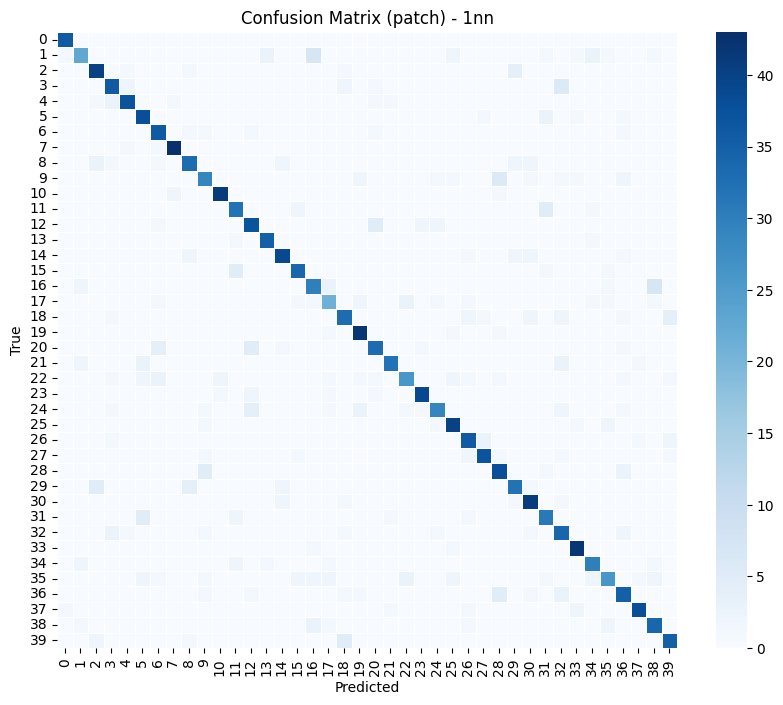

In [46]:
one_nn_patch_acc = test_gen_results.strategy_results['1nn']['patch'].metrics
logger.info(f"1nn - by patch accuracy {one_nn_patch_acc['accuracy']:.2f}")
viz.plot_confusion(level="patch")

**Vote-level Confusion Matrix**

The vote-level confusion matrix represents the final classification performance after aggregating predictions across multiple patches.

By combining information from several patches, the model achieves more robust and stable predictions, significantly reducing classification errors.

13:38:40 - mobile_test_40_4 - INFO - 1nn - by vote accuracy 1.0


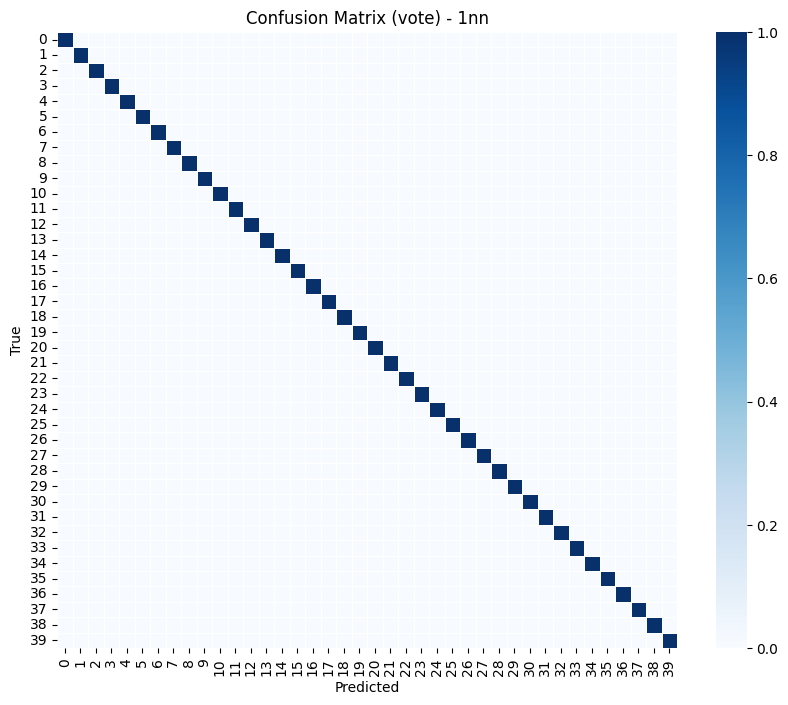

In [47]:
one_nn_vote_acc = test_gen_results.strategy_results['1nn']['vote'].metrics
logger.info(f"1nn - by vote accuracy {one_nn_vote_acc['accuracy']}")
viz.plot_confusion(level="vote")

**Score-level Confusion Matrix**

The score-level aggregation selects the final prediction by accumulating cosine similarity scores across all patches per (author, author_pred) pair, choosing the candidate with the highest total similarity.

Unlike vote-level aggregation, this approach weights predictions by confidence - a small number of high-similarity patches can outweigh a larger number of low-confidence ones. This makes score particulary effective for `1nn` and `topk` strategies, where similarity is a reliable signal.

13:38:45 - mobile_test_40_4 - INFO - 1nn - by score accuracy 1.00


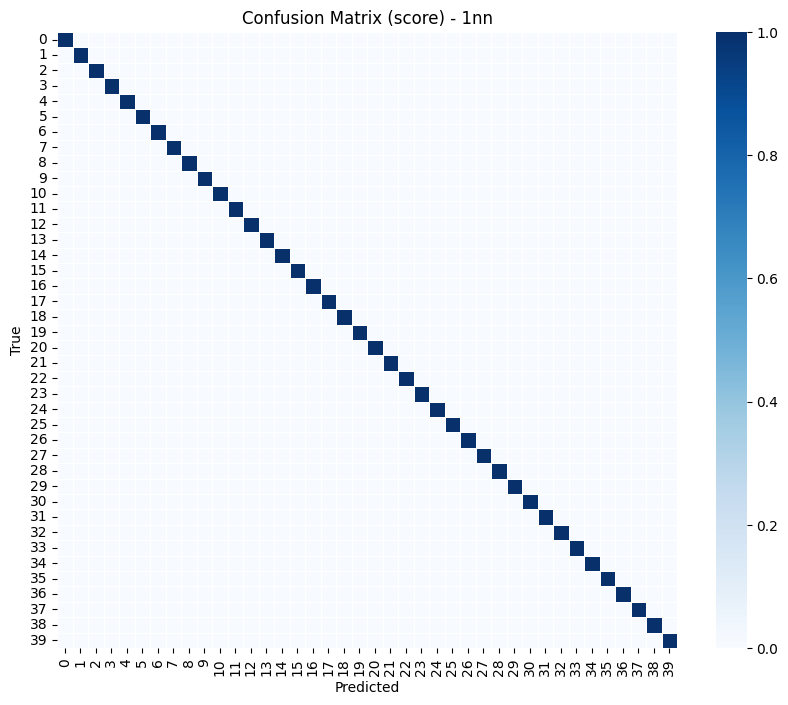

In [48]:
one_nn_score_acc = test_gen_results.strategy_results['1nn']['score'].metrics
logger.info(f"1nn - by score accuracy {one_nn_score_acc['accuracy']:.2f}")
viz.plot_confusion(level="score")

**Comparison**

The comparison between patch-level, vote-level, and score-level confusion matrices highlights different aggregation strategies and their trade-offs.

At the patch level, predictions are based on individual image regions and are therefore noisy and often ambiguous.

The vote-level aggregation reduces noise by combining multiple patch predictions through majority voting, improving stability regardless of prediction confidence.

The score-level aggregation replaces frequency with accumulated cosine similarity, favoring predictions supported by high-confidence matches over predictions supported by sheer count. This leads to stronger performance in neighbor-based strategies (1nn, topk), where similarity is a direct quality measure. For representation-based strategies (mean, centroid), vote-level aggregation can be equally or more effective.

No single aggregation level dominates universally — the optimal choice depends on the strategy used.

In [49]:
viz.set_strategy("topk")

In [50]:
viz.plot_embeddings()

In [51]:
viz.log_error_samples(n=20)

13:39:14 - mobile_test_40_4 - INFO - Showing 20 error samples:
13:39:14 - mobile_test_40_4 - INFO - [idx=861] true=lines1_Page_21 pred=lines1_Page_07 (author_id=20 → 6)
13:39:14 - mobile_test_40_4 - INFO - [idx=1066] true=lines1_Page_25 pred=lines1_Page_18 (author_id=24 → 17)
13:39:14 - mobile_test_40_4 - INFO - [idx=1335] true=lines1_Page_31 pred=lines1_Page_15 (author_id=30 → 14)
13:39:14 - mobile_test_40_4 - INFO - [idx=951] true=lines1_Page_23 pred=lines1_Page_27 (author_id=22 → 26)
13:39:14 - mobile_test_40_4 - INFO - [idx=725] true=lines1_Page_17 pred=lines1_Page_02 (author_id=16 → 1)
13:39:14 - mobile_test_40_4 - INFO - [idx=1062] true=lines1_Page_25 pred=lines1_Page_13 (author_id=24 → 12)
13:39:14 - mobile_test_40_4 - INFO - [idx=1126] true=lines1_Page_27 pred=lines1_Page_18 (author_id=26 → 17)
13:39:14 - mobile_test_40_4 - INFO - [idx=770] true=lines1_Page_19 pred=lines1_Page_27 (author_id=18 → 26)
13:39:14 - mobile_test_40_4 - INFO - [idx=945] true=lines1_Page_23 pred=lines1_

In [52]:
viz.plot_centroids()

13:39:16 - mobile_test_40_4 - INFO - Estimated DBSCAN eps=1.5378 | clusters=5


13:39:31 - mobile_test_40_4 - INFO - topk - by patch accuracy 0.74


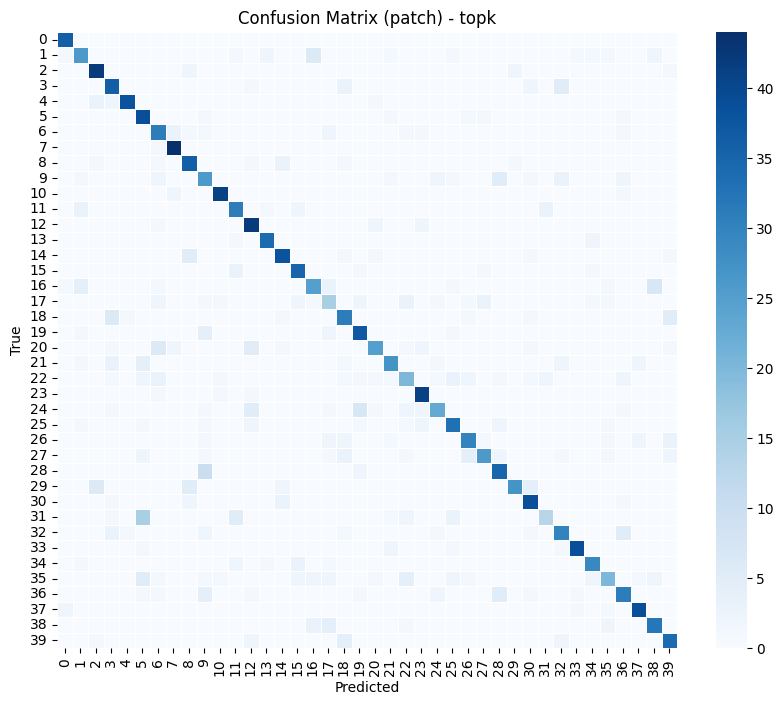

In [53]:
topk_patch_acc = test_gen_results.strategy_results['topk']['patch'].metrics
logger.info(f"topk - by patch accuracy {topk_patch_acc['accuracy']:.2f}")
viz.plot_confusion(level="patch")

13:39:36 - mobile_test_40_4 - INFO - topk - by vote accuracy 0.97


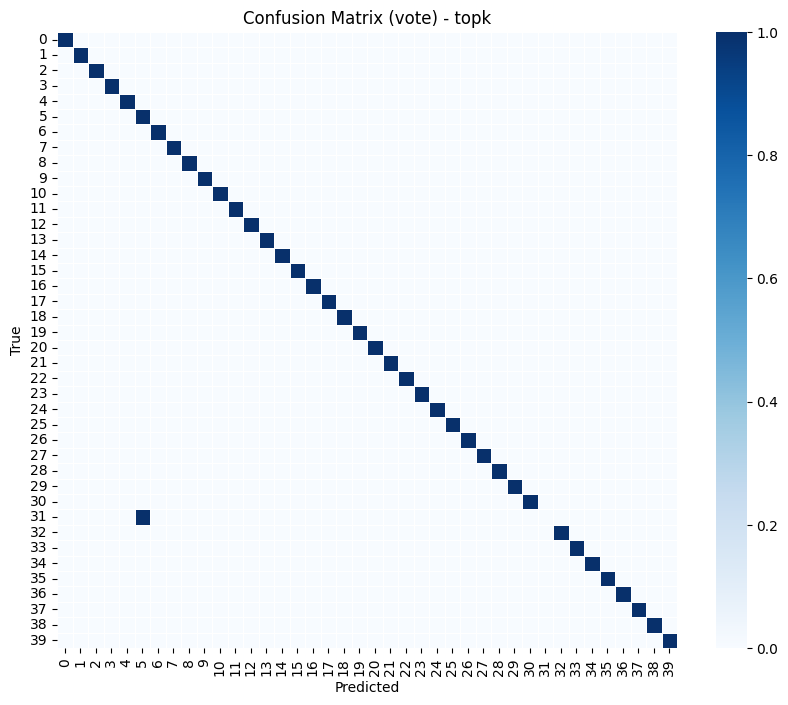

In [54]:
topk_vote_acc = test_gen_results.strategy_results['topk']['vote'].metrics
logger.info(f"topk - by vote accuracy {topk_vote_acc['accuracy']:.2f}")
viz.plot_confusion(level="vote")

In [55]:
res_topk_data = test_gen_results.strategy_results['topk']['vote'].data
topk_error_data = res_topk_data[res_topk_data['correct'] == False]
topk_error_data[['author', 'author_pred']]

,author,author_pred
31,31,5


In [56]:
viz.plot_centroids([5, 31])

13:40:00 - mobile_test_40_4 - INFO - Estimated DBSCAN eps=1.5378 | clusters=5
